# Decision Tree — UCI HAR Dataset
Dataset: UCI HAR (ID: 240)  
Thread 1: PyGoL vs Decision Tree vs Naive Bayes

Decision Trees learn axis-aligned splits on feature values — a propositional, non-relational approach. We compare this against PyGoL's relational rule learning to evaluate the benefit of relational structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('outputs/dt_har', exist_ok=True)

train_df = pd.read_csv('ucihar_train.csv')
test_df  = pd.read_csv('ucihar_test.csv')

drop_cols = ['activity','subject','split']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['activity']
X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df['activity']
activities = sorted(y_train.unique())

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Activities: {activities}")

Train: (7352, 561), Test: (2947, 561)
Activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


## 1. Model Training

In [2]:
model = DecisionTreeClassifier(random_state=42, max_depth=20, min_samples_leaf=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Tree depth    : {model.get_depth()}")
print(f"Tree leaves   : {model.get_n_leaves()}")
print(f"Features used : {(model.feature_importances_ > 0).sum()} / {X_train.shape[1]}")

Tree depth    : 15
Tree leaves   : 127
Features used : 102 / 561


## 2. Performance Metrics

In [3]:
acc  = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')
mcc  = matthews_corrcoef(y_test, y_pred)

le = LabelEncoder().fit(y_train)
y_test_enc = le.transform(y_test)
y_pred_enc = le.transform(y_pred)

print("=" * 55)
print("DECISION TREE — UCI HAR (Official Train/Test Split)")
print("=" * 55)
print(f"Accuracy           : {acc:.4f}")
print(f"Balanced Accuracy  : {bacc:.4f}")
print(f"Precision (macro)  : {prec:.4f}")
print(f"Recall (macro)     : {rec:.4f}")
print(f"F1 (macro)         : {f1:.4f}")
print(f"MCC                : {mcc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=activities))

DECISION TREE — UCI HAR (Official Train/Test Split)
Accuracy           : 0.8707
Balanced Accuracy  : 0.8676
Precision (macro)  : 0.8713
Recall (macro)     : 0.8676
F1 (macro)         : 0.8682
MCC                : 0.8451

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.86      0.76      0.80       491
          STANDING       0.80      0.88      0.84       532
           WALKING       0.85      0.91      0.88       496
WALKING_DOWNSTAIRS       0.89      0.85      0.87       420
  WALKING_UPSTAIRS       0.84      0.80      0.82       471

          accuracy                           0.87      2947
         macro avg       0.87      0.87      0.87      2947
      weighted avg       0.87      0.87      0.87      2947



## 3. Confusion Matrix

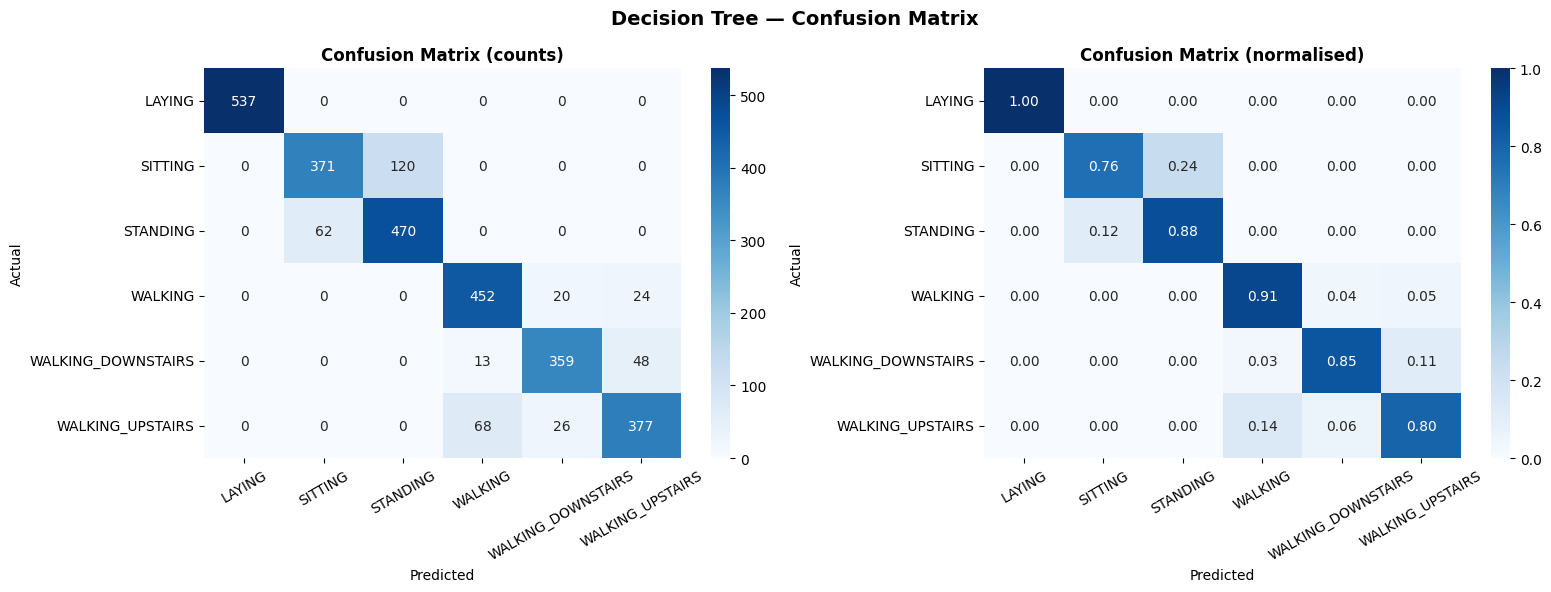

Saved: outputs/dt_har/01_confusion_matrix.png


In [4]:
cm = confusion_matrix(y_test, y_pred, labels=activities)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=activities, yticklabels=activities)
axes[0].set_title('Confusion Matrix (counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=activities, yticklabels=activities)
axes[1].set_title('Confusion Matrix (normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Decision Tree — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/dt_har/01_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/dt_har/01_confusion_matrix.png")

## 4. Per-Activity Results

Activity                      Acc    Prec     Rec      F1
----------------------------------------------------------
LAYING                      1.000   1.000   1.000   1.000
SITTING                     0.756   0.857   0.756   0.803
STANDING                    0.883   0.797   0.883   0.838
WALKING                     0.911   0.848   0.911   0.879
WALKING_DOWNSTAIRS          0.855   0.886   0.855   0.870
WALKING_UPSTAIRS            0.800   0.840   0.800   0.820


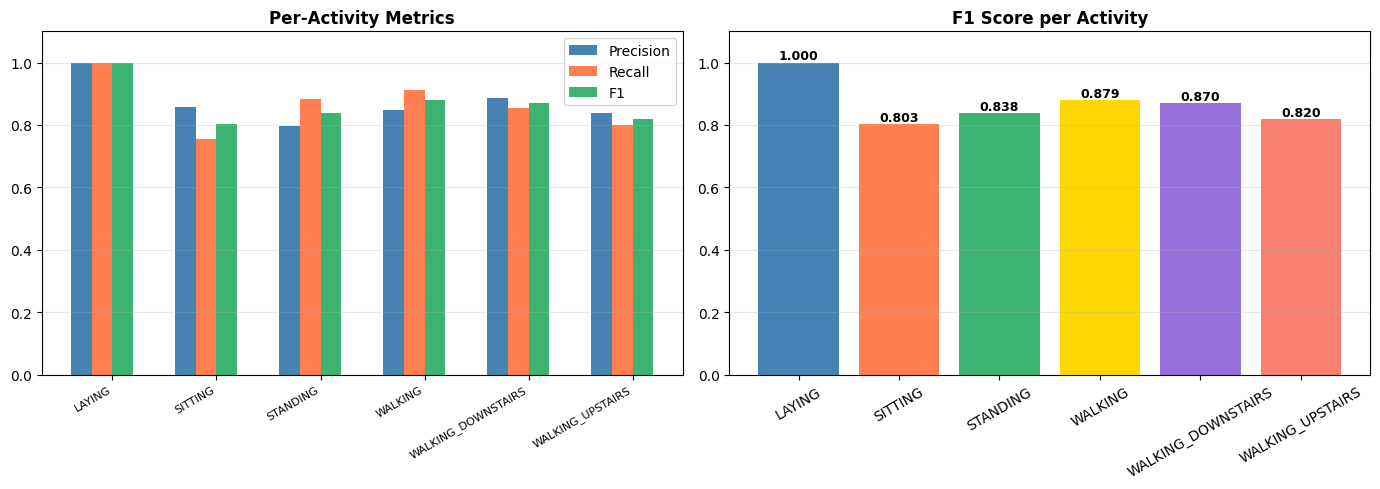


Saved: outputs/dt_har/dt_har_results.csv


In [5]:
prec_per = precision_score(y_test, y_pred, average=None, labels=activities)
rec_per  = recall_score(y_test, y_pred, average=None, labels=activities)
f1_per   = f1_score(y_test, y_pred, average=None, labels=activities)
colors   = ['steelblue','coral','mediumseagreen','gold','mediumpurple','salmon']

results = []
print(f"{'Activity':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("-" * 58)
for i, act in enumerate(activities):
    acc_act = (y_test[y_test==act]==y_pred[y_test==act]).mean()
    print(f"{act:<25} {acc_act:>7.3f} {prec_per[i]:>7.3f} {rec_per[i]:>7.3f} {f1_per[i]:>7.3f}")
    results.append({'activity': act, 'accuracy': round(acc_act,4),
                    'precision': round(prec_per[i],4), 'recall': round(rec_per[i],4),
                    'f1': round(f1_per[i],4)})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(activities))
w = 0.2
axes[0].bar(x-w*1.5, prec_per, w, label='Precision', color='steelblue')
axes[0].bar(x-w*0.5, rec_per,  w, label='Recall',    color='coral')
axes[0].bar(x+w*0.5, f1_per,   w, label='F1',        color='mediumseagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(activities, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Per-Activity Metrics', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.1)

axes[1].bar(activities, f1_per, color=colors)
axes[1].set_title('F1 Score per Activity', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_per):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/dt_har/02_per_activity_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

res_df = pd.DataFrame(results)
res_df['algorithm'] = 'Decision Tree'
res_df.to_csv('outputs/dt_har/dt_har_results.csv', index=False)
print("\nSaved: outputs/dt_har/dt_har_results.csv")

## 5. Feature Importance

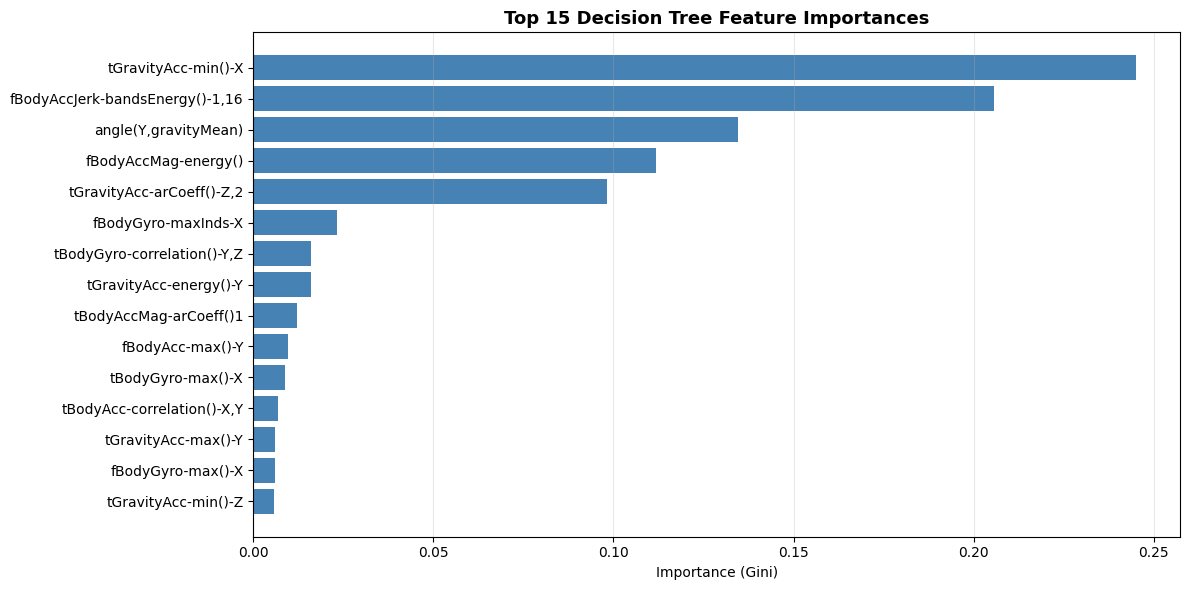


Top 5 features: ['tGravityAcc-min()-X', 'fBodyAccJerk-bandsEnergy()-1,16', 'angle(Y,gravityMean)', 'fBodyAccMag-energy()', 'tGravityAcc-arCoeff()-Z,2']
Saved: outputs/dt_har/03_feature_importance.png


In [6]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
top15 = feat_imp.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color='steelblue')
ax.set_title('Top 15 Decision Tree Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/dt_har/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
feat_imp.to_csv('outputs/dt_har/dt_feature_importance.csv', index=False)
print(f"\nTop 5 features: {feat_imp.head(5)['feature'].tolist()}")
print("Saved: outputs/dt_har/03_feature_importance.png")

## 6. Tree Depth Analysis

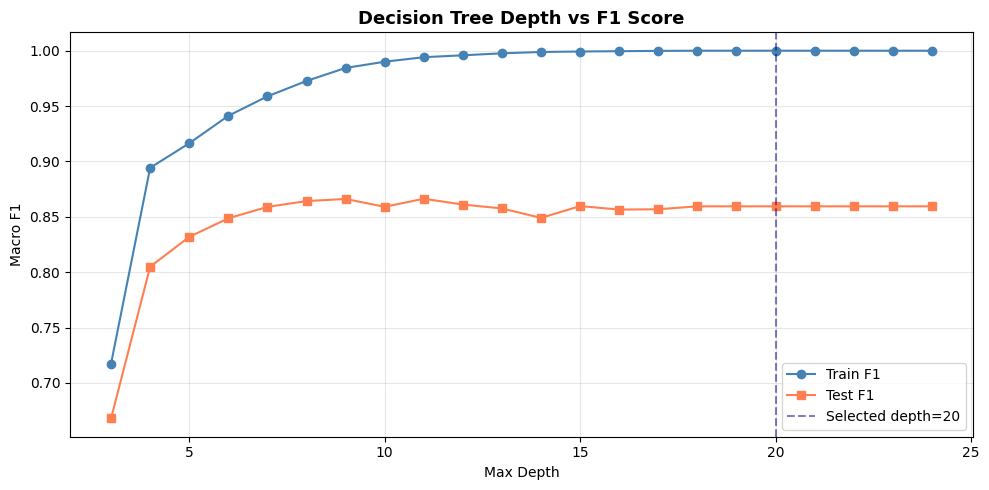

Saved: outputs/dt_har/04_depth_analysis.png
Best test F1 at depth=11: 0.8663


In [7]:
depths = range(3, 25)
train_f1s, test_f1s = [], []
for d in depths:
    m = DecisionTreeClassifier(random_state=42, max_depth=d)
    m.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, m.predict(X_train), average='macro'))
    test_f1s.append(f1_score(y_test,  m.predict(X_test),  average='macro'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_f1s, 'o-', color='steelblue', label='Train F1')
ax.plot(depths, test_f1s,  's-', color='coral',     label='Test F1')
ax.axvline(20, color='navy', linestyle='--', alpha=0.5, label='Selected depth=20')
ax.set_title('Decision Tree Depth vs F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Macro F1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/dt_har/04_depth_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/dt_har/04_depth_analysis.png")

best_depth = depths[np.argmax(test_f1s)]
print(f"Best test F1 at depth={best_depth}: {max(test_f1s):.4f}")

## Summary

In [8]:
print("=" * 55)
print("DECISION TREE — FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"Accuracy           : {acc:.4f}")
print(f"Balanced Accuracy  : {bacc:.4f}")
print(f"Macro Precision    : {prec:.4f}")
print(f"Macro Recall       : {rec:.4f}")
print(f"Macro F1           : {f1:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"Tree Depth         : {model.get_depth()}")
print(f"Tree Leaves        : {model.get_n_leaves()}")
print(f"\nBest activity : LAYING    (F1=1.000 — perfectly identifiable)")
print(f"Worst activity: SITTING   (F1={f1_per[activities.index('SITTING')]:.3f} — confused with STANDING)")
print(f"\nOutput files saved to: outputs/dt_har/")

DECISION TREE — FINAL RESULTS SUMMARY
Accuracy           : 0.8707
Balanced Accuracy  : 0.8676
Macro Precision    : 0.8713
Macro Recall       : 0.8676
Macro F1           : 0.8682
MCC                : 0.8451
Tree Depth         : 15
Tree Leaves        : 127

Best activity : LAYING    (F1=1.000 — perfectly identifiable)
Worst activity: SITTING   (F1=0.803 — confused with STANDING)

Output files saved to: outputs/dt_har/
